In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

**(a)**

In [16]:
# datapoints
a1 = np.array([-6,-1])
a2 = np.array([0,5])
a3 = np.array([7,-8])
m=3

In [17]:
X = np.zeros((m,2),dtype=np.float64)

X[0,:] = a1
X[1,:] = a2
X[2,:] = a3

In [18]:
# subdifferential of sum of norms ||x-a_i||
def subdifferential(y):
  subdiff = 0

  for i in range(3):
    if not np.array_equal(y,X[i,:]):
      subdiff+=(y-X[i,:])/np.linalg.norm(y-X[i,:])

  return subdiff


In [19]:
# subgradient method
def subgradient_method(initial_guess,learning_rate= 0.001, max_iterations = 10000, tol=1e-6):
  x = initial_guess

  # subgradient descent iteration
  x_new = x - learning_rate*subdifferential(x)

  for i in range(2,max_iterations):
    # terminating condition
    if np.linalg.norm(x_new-x) < tol:
      break
    x = x_new
    subdiff = subdifferential(x)

    # subgradient descent iteration
    x_new =x-learning_rate*subdiff

  return x_new

In [20]:
initial_guess = X[0,:]
optimal_solution = subgradient_method(initial_guess)

In [21]:
optimal_solution

array([-2.21469099, -0.18085937])

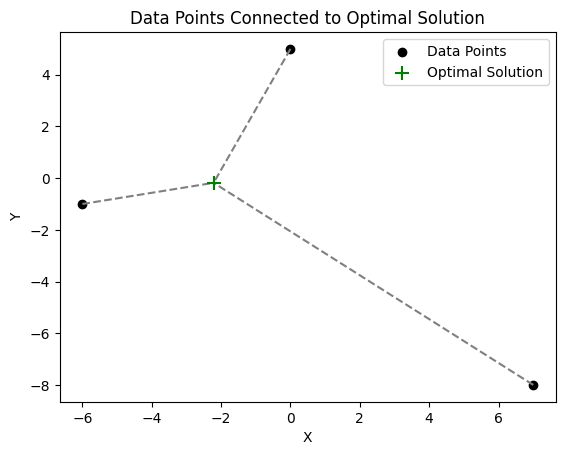

In [22]:
for i in range(len(X)):
    plt.plot([X[i, 0], optimal_solution[0]], [X[i, 1], optimal_solution[1]], color='gray', linestyle='--')

plt.scatter(X[:, 0], X[:, 1], color='black', marker='o', label='Data Points')

plt.scatter(optimal_solution[0], optimal_solution[1], color='green', s=100, zorder=5,marker='+', label='Optimal Solution')

plt.title('Data Points Connected to Optimal Solution')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

**(b)**

In [23]:
df = pd.read_excel('USCity.xlsx',header=None)
df.sample(5)

,0,1
1215,44.55,110.42
267,33.63,116.17
1116,43.53,73.95
992,44.30,96.80
9,30.68,88.25


In [24]:
X = df.to_numpy()
m = X.shape[0]
m

1217

In [ ]:
# choosing a datapoint as initial guess at random
initial_guess = X[np.random.randint(m),:]
optimal_solution = subgradient_method(initial_guess)

In [26]:
optimal_solution

array([33.52829841, 85.88321942])

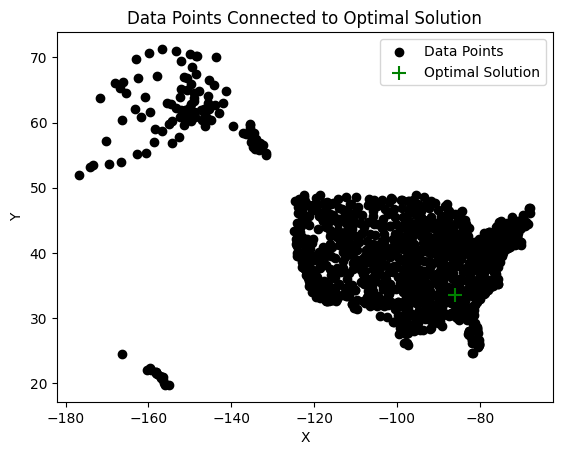

In [27]:
# thinking of first coordinate in the dataset as latitutde and second coordinate as -longitude
plt.scatter(-X[:, 1], X[:, 0], color='black', marker='o', label='Data Points')

plt.scatter(-optimal_solution[1], optimal_solution[0], color='green', s=100, marker = '+',zorder=5, label='Optimal Solution')

plt.title('Data Points Connected to Optimal Solution')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()